# Task 1: Diagnostic Enhancement of Chest X-Rays

Goal: mathematically process underexposed, single-channel chest X-ray matrices to maximize structural visibility before they go to the diagnostic doctors.

**Pipeline:** Load → Histogram Equalization → JET Color Map → Color Balance → Threshold (dense tissue) → Log Transform → Power-Law (Gamma)

## 0. Setup & Configuration

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------ PLACEHOLDERS: EDIT THESE ------------------
IMAGE_PATH = Path.cwd() / "data" / "NORMAL.png"   # <-- path to a sample grayscale X-ray
OUTPUT_DIR = Path.cwd() / "output"         # <-- where processed images are saved
SAVE_OUTPUTS = True           
# --------------------------------------------------------------

# Tunable parameters
THRESHOLD_VALUE = 200                        # Task 5: intensity cutoff (0-255) for dense tissue
GAMMA_VALUES = [0.3, 0.5, 0.7, 0.9]          # Task 6: all < 1.0
GAMMA_CHOSEN = 0.6                           # Task 6: gamma used for the final output

if SAVE_OUTPUTS:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(name, img):
    if SAVE_OUTPUTS:
        cv2.imwrite(os.path.join(OUTPUT_DIR, name), img)

def show_pair(a, b, title_a, title_b, cmap_a="gray", cmap_b="gray", figsize=(12, 6)):
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    ax[0].imshow(a, cmap=cmap_a); ax[0].set_title(title_a); ax[0].axis("off")
    ax[1].imshow(b, cmap=cmap_b); ax[1].set_title(title_b); ax[1].axis("off")
    plt.tight_layout(); plt.show()

def show_hist(images, titles, figsize=(14, 3.5)):
    fig, ax = plt.subplots(1, len(images), figsize=figsize)
    ax = np.atleast_1d(ax)
    for a, im, t in zip(ax, images, titles):
        a.hist(im.ravel(), bins=256, range=(0, 255), color="steelblue")
        a.set_title(t); a.set_xlabel("Intensity"); a.set_ylabel("Pixels")
    plt.tight_layout(); plt.show()

## 1. Load and Display

Shape: (232, 232) | dtype: uint8
Min / Max / Mean: 0 255 140.72


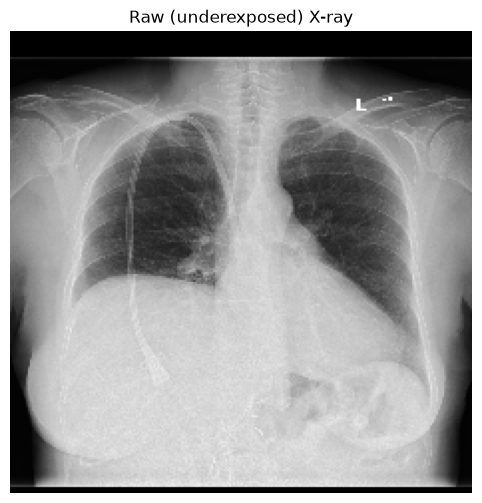

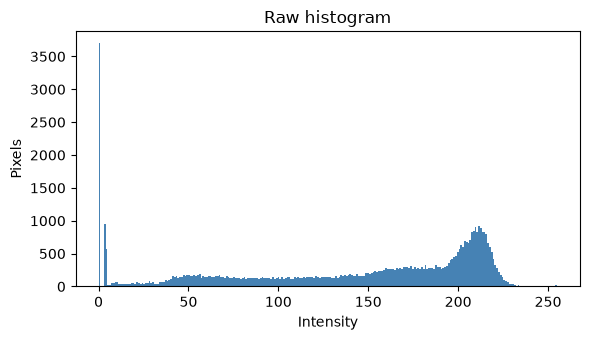

In [4]:
raw = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if raw is None:
    raise FileNotFoundError(f"Could not read image at: {IMAGE_PATH}. Update IMAGE_PATH.")

print("Shape:", raw.shape, "| dtype:", raw.dtype)
print("Min / Max / Mean:", raw.min(), raw.max(), round(raw.mean(), 2))

plt.figure(figsize=(6, 6))
plt.imshow(raw, cmap="gray", vmin=0, vmax=255)
plt.title("Raw (underexposed) X-ray"); plt.axis("off"); plt.show()

show_hist([raw], ["Raw histogram"], figsize=(6, 3.5))

**Observation:** The raw radiograph has a broad intensity range (0-255) with a mean of about 140.72. The two lung fields, mediastinum, ribs, spine, and cardiac silhouette are visible, although the darker lung markings and the outer rib margins have relatively low contrast. The bright lower thoracic and cardiac regions dominate the image, so subtle soft-tissue differences are harder to separate visually.

## 2. Contrast Enhancement: Histogram Equalization

Histogram equalization remaps intensities using the cumulative distribution function (CDF) of the image:

$$s_k = \text{round}\left(\frac{CDF(r_k) - CDF_{min}}{N - CDF_{min}} \times 255\right)$$

This spreads the crowded low-intensity values across the full 0–255 range.

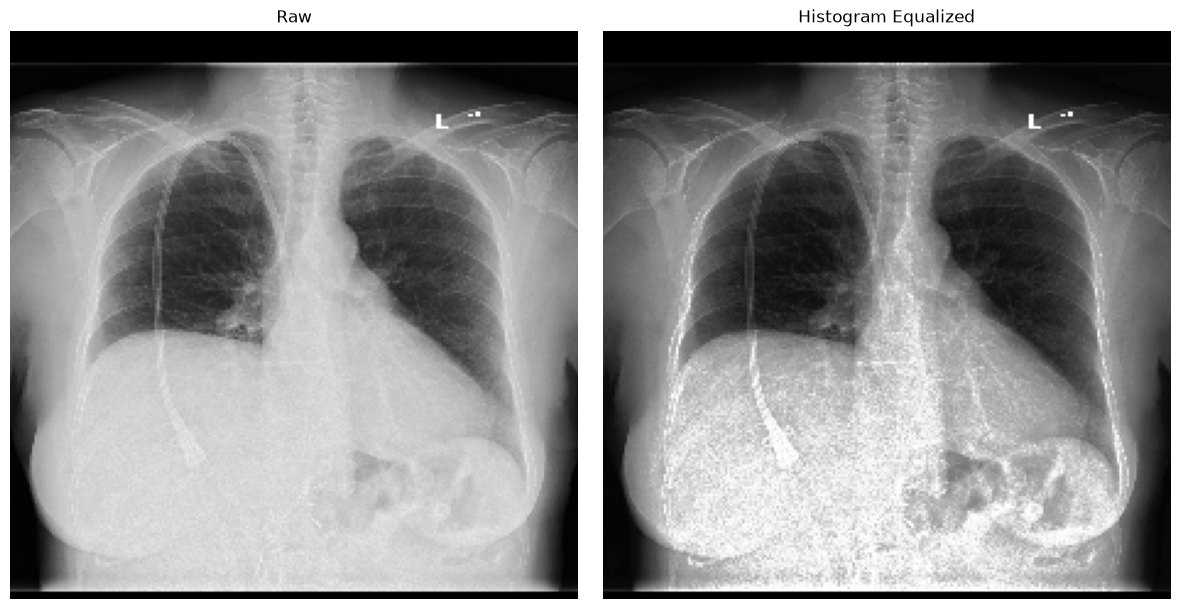

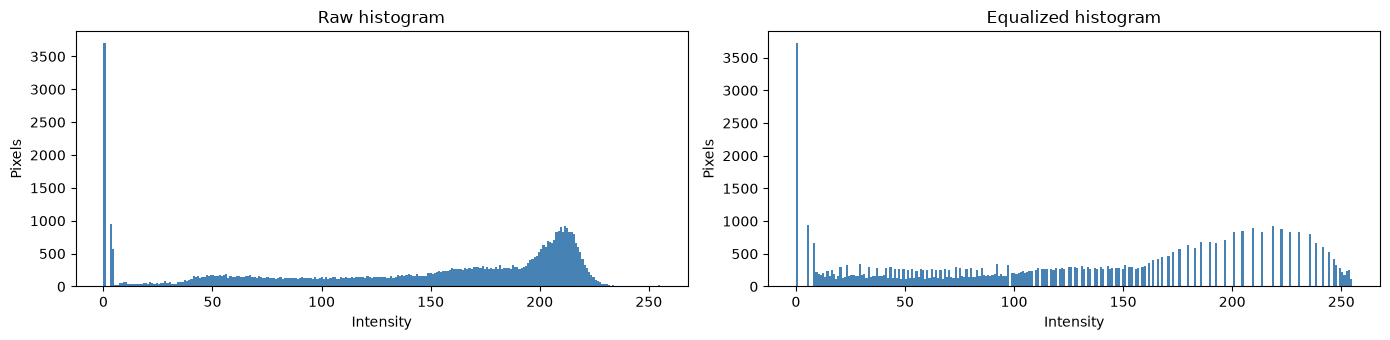

Raw       -> mean: 140.7, std (contrast): 72.7
Equalized -> mean: 119.7, std (contrast): 78.6


In [5]:
equalized = cv2.equalizeHist(raw)

show_pair(raw, equalized, "Raw", "Histogram Equalized")
show_hist([raw, equalized], ["Raw histogram", "Equalized histogram"])
save("02_equalized.png", equalized)

# Quantitative comparison
print(f"Raw       -> mean: {raw.mean():.1f}, std (contrast): {raw.std():.1f}")
print(f"Equalized -> mean: {equalized.mean():.1f}, std (contrast): {equalized.std():.1f}")

**Observation:** Equalization expands the contrast in the lung fields and makes peripheral rib edges, the spine, vascular/bronchial markings, and the lung-field boundaries more conspicuous. Fine texture is easier to see in the darker regions, but the transformation also makes granular noise and high-density regions in the lower chest more prominent. This improves visibility of structures but does not by itself establish that an opacity represents fluid or another abnormality.

## 3. Color Mapping: COLORMAP_JET

Mapping intensity to a color spectrum (blue = low, green/yellow = mid, red = high) lets the eye separate many more levels than the ~30–60 gray shades a human can distinguish, making subtle fluid boundaries easier to spot.

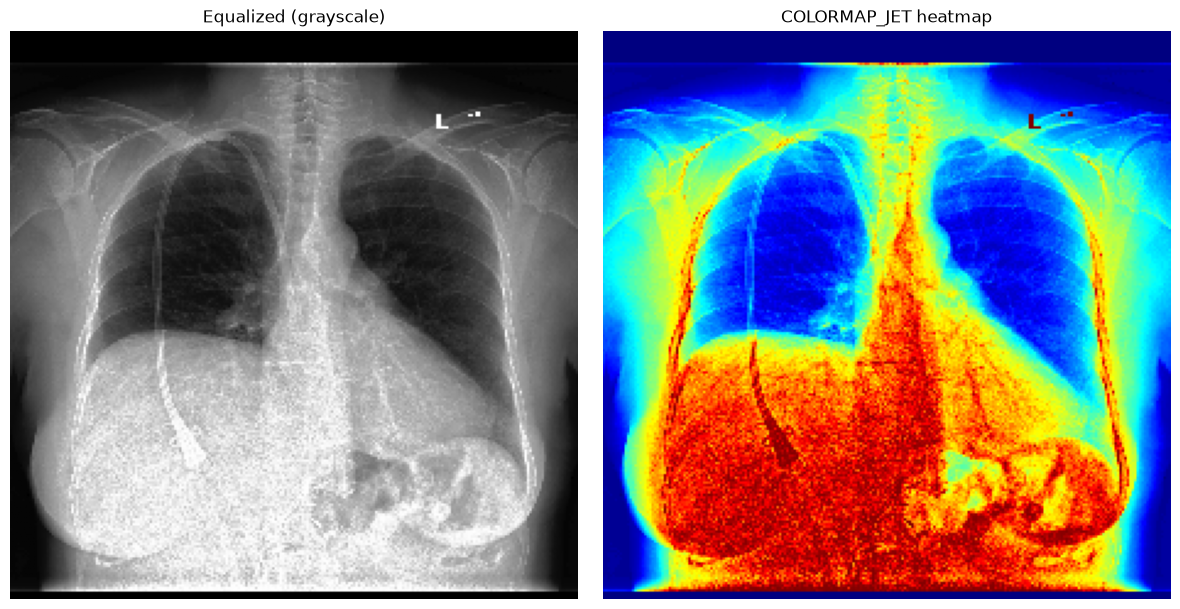

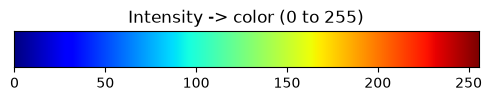

In [6]:
jet_bgr = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
jet_rgb = cv2.cvtColor(jet_bgr, cv2.COLOR_BGR2RGB)

show_pair(equalized, jet_rgb, "Equalized (grayscale)", "COLORMAP_JET heatmap", cmap_b=None)
save("03_jet.png", jet_bgr)

# Colorbar reference
plt.figure(figsize=(6, 1))
plt.imshow(np.tile(np.arange(256, dtype=np.uint8), (20, 1)), cmap="jet")
plt.title("Intensity -> color (0 to 255)"); plt.yticks([]); plt.show()

**Observation:** The JET map separates intensity bands into blue, cyan/green, yellow, and red. The lungs remain predominantly blue-to-cyan, while the mediastinum, ribs, diaphragm, and cardiac/lower-chest regions move toward yellow and red. These sharp color transitions make boundaries and intensity gradients easier to localize than in grayscale, but the colors represent intensity only and should not be interpreted as tissue labels.

## 4. Color Balance (Lighting Correction)

Simulate a lighting correction with a per-channel gain (von Kries / gray-world model) that neutralizes artificial color casts:

$$C'_{c} = \text{clip}(g_c \cdot C_c, 0, 255), \qquad g_c = \frac{\mu_{gray}}{\mu_c}$$

where $\mu_c$ is the mean of channel $c$ and $\mu_{gray}$ is the mean of all channel means. Manual gains are also provided for fine control.

Channel means (B, G, R): [119.9 117.1 111.5]
Gains (B, G, R):        [0.969 0.992 1.042]


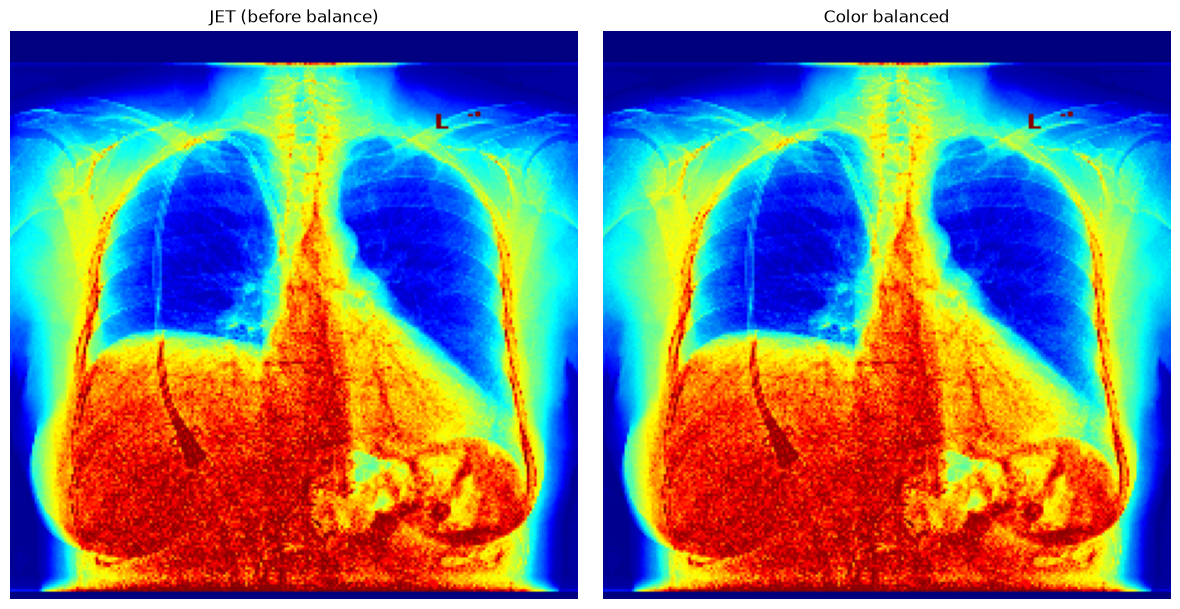

In [7]:
def gray_world_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    means = img.reshape(-1, 3).mean(axis=0)          # [B, G, R]
    gains = means.mean() / means
    print("Channel means (B, G, R):", np.round(means, 1))
    print("Gains (B, G, R):       ", np.round(gains, 3))
    return np.clip(img * gains, 0, 255).astype(np.uint8)

def manual_balance(img_bgr, gain_b=1.0, gain_g=1.0, gain_r=1.0):
    gains = np.array([gain_b, gain_g, gain_r], dtype=np.float32)
    return np.clip(img_bgr.astype(np.float32) * gains, 0, 255).astype(np.uint8)

balanced_bgr = gray_world_balance(jet_bgr)
# Alternative: balanced_bgr = manual_balance(jet_bgr, gain_b=1.1, gain_g=1.0, gain_r=0.9)
balanced_rgb = cv2.cvtColor(balanced_bgr, cv2.COLOR_BGR2RGB)

show_pair(jet_rgb, balanced_rgb, "JET (before balance)", "Color balanced", cmap_a=None, cmap_b=None)
save("04_color_balanced.png", balanced_bgr)

**Observation:** Color balancing produces only a small visual change because the JET image already has a strong, deliberately encoded color range. The dominant blue lung fields and warm high-intensity cardiac, rib, and lower-chest regions remain in the same locations, with slightly more even channel balance. The result is marginally less affected by channel bias, but the original JET image is already easier to compare because its intensity-to-color mapping is consistent.

## 5. Color Filtering (Thresholding)

Dense tissue (bone, dense fluid) has high intensity. A strict binary threshold keeps only pixels above `THRESHOLD_VALUE`:

$$M(x,y) = \begin{cases} 255 & I(x,y) > T \\ 0 & \text{otherwise} \end{cases}$$

The mask is then applied to the image so only the densest tissue remains.

Chosen threshold: 200 | Otsu suggestion: 119
Pixels retained: 21.35%


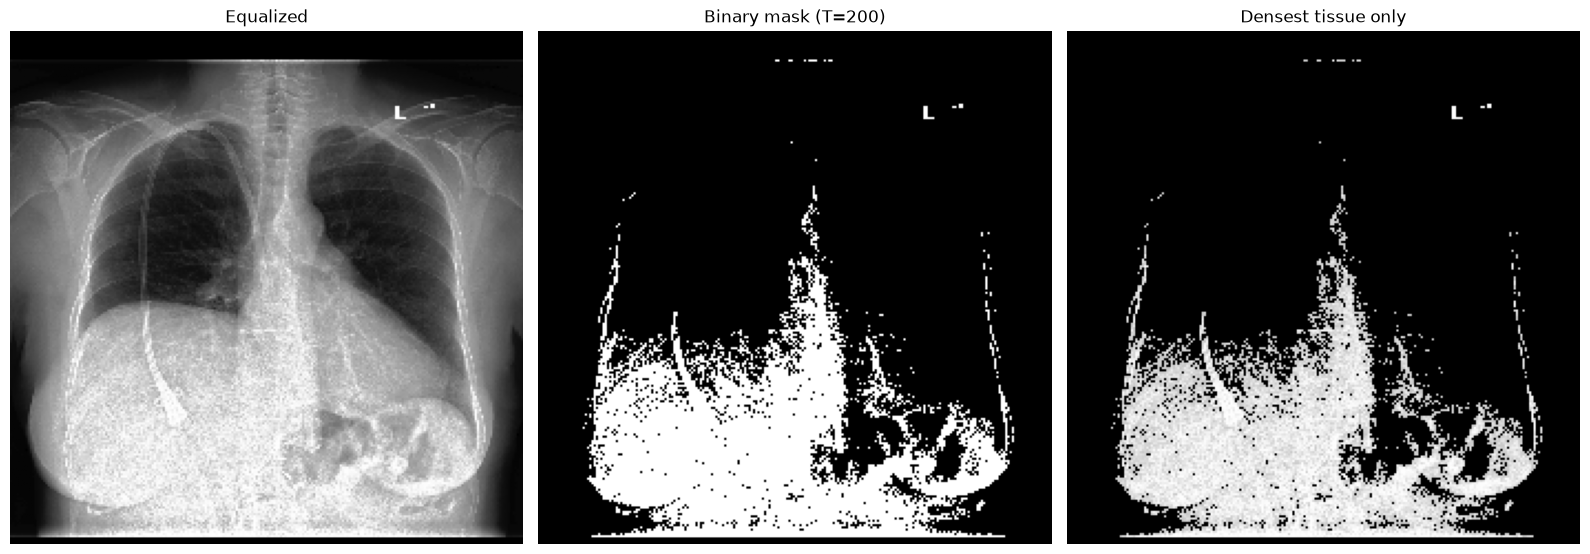

In [8]:
_, mask = cv2.threshold(equalized, THRESHOLD_VALUE, 255, cv2.THRESH_BINARY)
dense_only = cv2.bitwise_and(equalized, equalized, mask=mask)

# Optional: data-driven threshold for reference (Otsu)
otsu_t, _ = cv2.threshold(equalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Chosen threshold: {THRESHOLD_VALUE} | Otsu suggestion: {otsu_t:.0f}")
print(f"Pixels retained: {100 * (mask > 0).mean():.2f}%")

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
for a, im, t in zip(ax, [equalized, mask, dense_only],
                    ["Equalized", f"Binary mask (T={THRESHOLD_VALUE})", "Densest tissue only"]):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

save("05_threshold_mask.png", mask)
save("05_dense_tissue.png", dense_only)

**Observation:** At the threshold value of 200, the mask keeps the brightest dense structures: much of the cardiac and lower thoracic silhouette, the spine and central bony detail, portions of the ribs, and other very bright markings. Most aerated lung tissue is removed, leaving only scattered high-intensity vascular or bony pixels. This is useful for isolating dense regions, but it discards too much context for general lung assessment and is not a diagnostic segmentation.

## 6. Logarithmic Transformation

Applied to the **raw** image to expand dark regions and compress bright ones:

$$s = c \cdot \log(1 + r), \qquad c = \frac{255}{\log(1 + r_{max})}$$

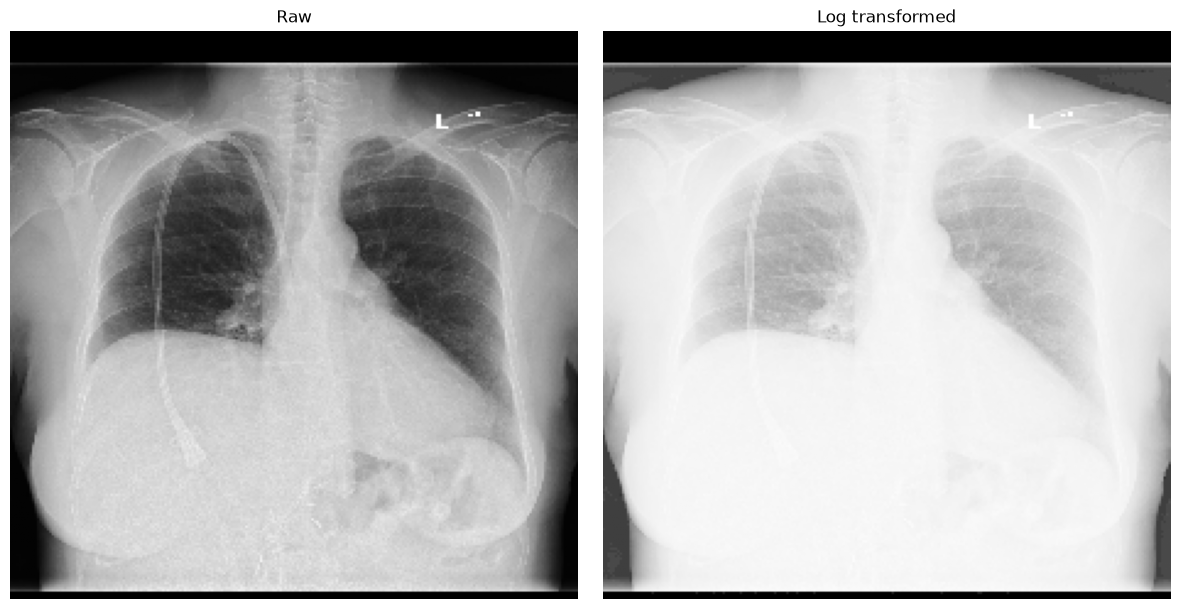

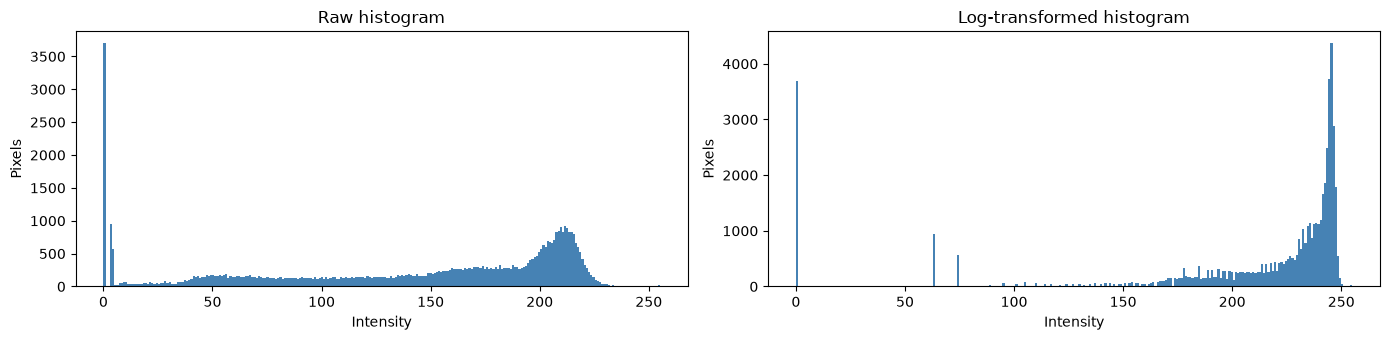

In [9]:
raw_f = raw.astype(np.float32)
c = 255.0 / np.log(1.0 + raw_f.max())
log_img = (c * np.log(1.0 + raw_f)).astype(np.uint8)

show_pair(raw, log_img, "Raw", "Log transformed")
show_hist([raw, log_img], ["Raw histogram", "Log-transformed histogram"])
save("06_log.png", log_img)

**Observation:** The logarithmic transform brightens the darker lung and background values while compressing the already bright cardiac and lower-chest regions. Faint peripheral ribcage edges and low-contrast lung texture become easier to see, although the image appears flatter and the brightest structures lose some separation. It is helpful for inspecting dark-region detail rather than for preserving a natural radiographic appearance.

## 7. Power-Law (Gamma) Transformation, $\gamma < 1.0$

$$s = 255 \cdot \left(\frac{r}{255}\right)^{\gamma}$$

With $\gamma < 1$ the curve brightens the dark and mid-tones, fine-tuning the midtones where lung tissue lives.

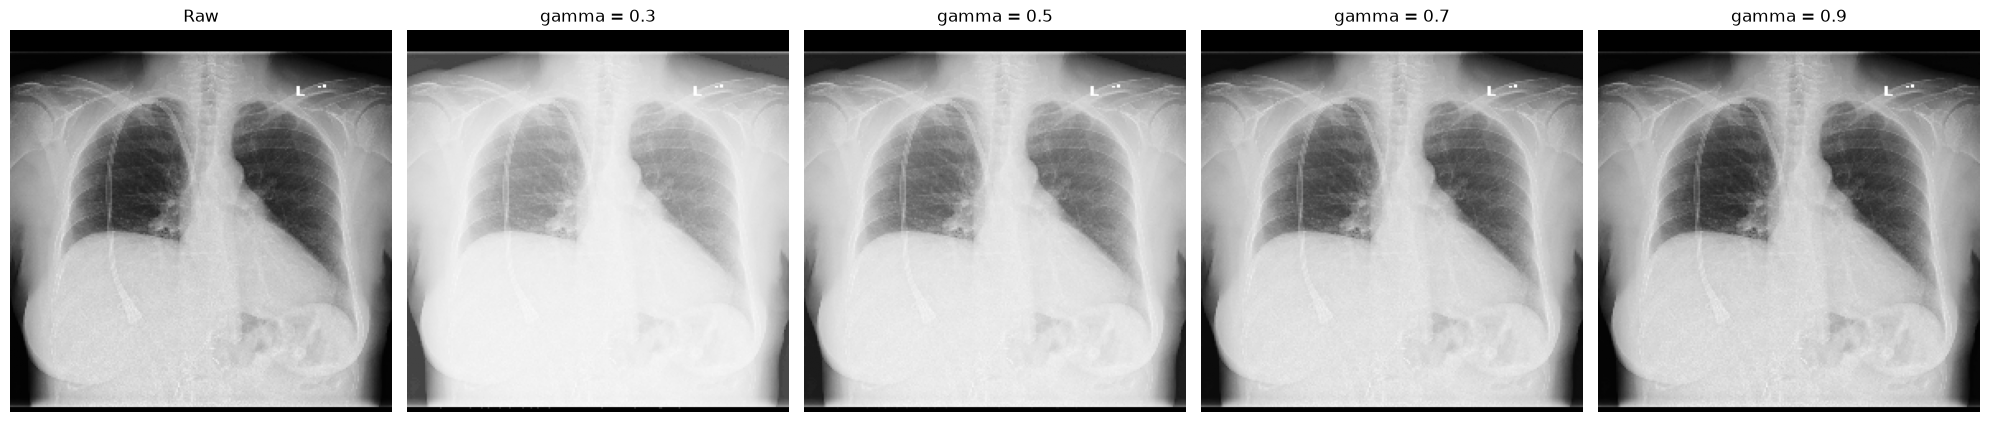

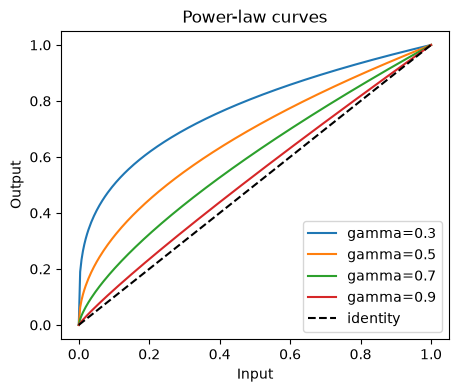

In [10]:
def gamma_transform(img, gamma):
    norm = img.astype(np.float32) / 255.0
    return np.clip(255.0 * np.power(norm, gamma), 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, len(GAMMA_VALUES) + 1, figsize=(4 * (len(GAMMA_VALUES) + 1), 4.5))
ax[0].imshow(raw, cmap="gray", vmin=0, vmax=255); ax[0].set_title("Raw"); ax[0].axis("off")
for a, g in zip(ax[1:], GAMMA_VALUES):
    a.imshow(gamma_transform(raw, g), cmap="gray", vmin=0, vmax=255)
    a.set_title(f"gamma = {g}"); a.axis("off")
plt.tight_layout(); plt.show()

# Transfer curves
x = np.linspace(0, 1, 256)
plt.figure(figsize=(5, 4))
for g in GAMMA_VALUES:
    plt.plot(x, x ** g, label=f"gamma={g}")
plt.plot(x, x, "k--", label="identity")
plt.xlabel("Input"); plt.ylabel("Output"); plt.legend(); plt.title("Power-law curves"); plt.show()

gamma_img = gamma_transform(raw, GAMMA_CHOSEN)
save("07_gamma.png", gamma_img)

**Observation:** The gamma values below 1 brighten dark and midtone pixels. The lower values (0.3 and 0.5) produce the strongest lift but risk washing out the lung and cardiac midtones; 0.7 and 0.9 preserve more tonal separation. The selected gamma of 0.6 provides a practical compromise: lung texture and midtone markings are more visible than in the raw image without completely flattening the bright ribs and cardiac silhouette.

## 8. Summary Comparison

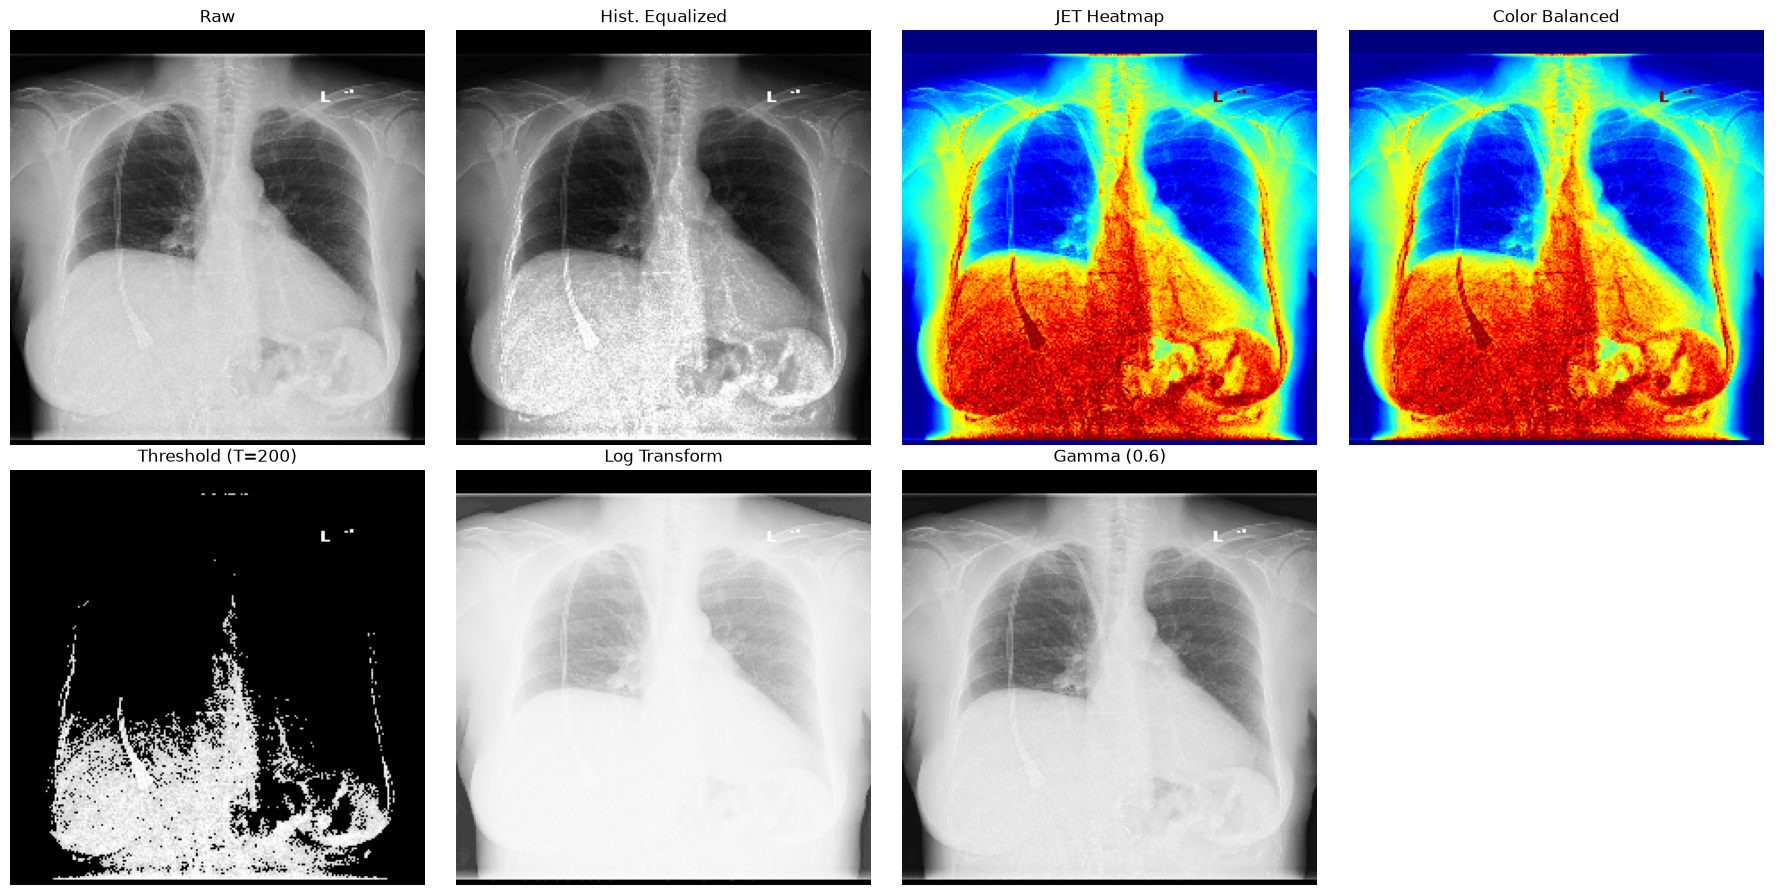

In [11]:
panels = [
    (raw, "Raw", "gray"),
    (equalized, "Hist. Equalized", "gray"),
    (jet_rgb, "JET Heatmap", None),
    (balanced_rgb, "Color Balanced", None),
    (dense_only, f"Threshold (T={THRESHOLD_VALUE})", "gray"),
    (log_img, "Log Transform", "gray"),
    (gamma_img, f"Gamma ({GAMMA_CHOSEN})", "gray"),
]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for a in axes.ravel(): a.axis("off")
for a, (im, t, cm) in zip(axes.ravel(), panels):
    a.imshow(im, cmap=cm, vmin=0 if cm else None, vmax=255 if cm else None); a.set_title(t)
plt.tight_layout(); plt.show()

### Conclusions
Histogram equalization gives the strongest overall structural enhancement by increasing visibility of rib edges, lung markings, and field boundaries, but it also amplifies noise. The logarithmic and gamma transforms are useful complementary views for dark and midtone detail; the selected gamma of 0.6 gives a balanced result. JET color mapping and color balancing help visually localize intensity transitions, while the threshold mask is best treated as a dense-tissue aid because it removes most lung context. A reasonable hand-off pipeline is the original image followed by equalization, a moderate gamma/log view, and the color/threshold views as supplementary displays. These processed images improve visual inspection but should not be used alone to diagnose fluid, consolidation, or other pathology.